# 5CS037 Final Portfolio Project — Regression Task

**Dataset:** realtor-data.zip.csv.

**Source:** News Corp subsidiary Move, Inc. (https://www.realtor.com/)

**Published:** 2024, Ahmed Shahriar Sakib

**Available at:** www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset [Kaggle]

**UNSDG:** Goal 11 (Housing affordability, city/community planning).

**Purpose:** To identify relation between house prices and features.

**Features:** brokered by, status, price, bed, bath, acre_lot, street, city, state, zip_code, house_size, prev_sold_date.

**Features Count**: 12.

**Target Feature:** price.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import ParameterGrid, ParameterSampler

RANDOM_STATE = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [34]:
# Load the dataset
raw_data = pd.read_csv("/content/drive/MyDrive/BINOD2/realtor-data.zip.csv.zip")

print("Dataset shape:", raw_data.shape)
print("Column names:", raw_data.columns.tolist())

# Basic exploration
display(raw_data.head())
display(raw_data.info())
display(raw_data.describe(include="all").T)

Dataset shape: (2226382, 12)
Column names: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brokered_by,2221849.0,NaN,NaN,NaN,52939.893287,30642.752884,0.0,23861.0,52884.0,79183.0,110142.0
status,2226382,3,for_sale,1389306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,2224841.0,NaN,NaN,NaN,524195.519291,2138893.221116,0.0,165000.0,325000.0,550000.0,2147483600.0
bed,1745065.0,NaN,NaN,NaN,3.275841,1.567274,1.0,3.0,3.0,4.0,473.0
bath,1714611.0,NaN,NaN,NaN,2.49644,1.652573,1.0,2.0,2.0,3.0,830.0
acre_lot,1900793.0,NaN,NaN,NaN,15.223027,762.823802,0.0,0.15,0.26,0.98,100000.0
street,2215516.0,NaN,NaN,NaN,1012324.920665,583763.478326,0.0,506312.75,1012765.5,1521173.25,2001357.0
city,2224975,20098,Houston,23862,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,2226374,55,Florida,249432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,2226083.0,NaN,NaN,NaN,52186.676341,28954.084538,0.0,29617.0,48382.0,78070.0,99999.0


In [35]:
# Dataset summary
def get_column_info(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_count": df.nunique(dropna=True)
    }).sort_values(by="missing_pct", ascending=False)

    return summary

# Generate and display column summary
column_summary = get_column_info(raw_data)
display(column_summary)

,dtype,missing_count,missing_pct,unique_count
prev_sold_date,object,734297,32.98,14954
house_size,float64,568484,25.53,12061
bath,float64,511771,22.99,86
bed,float64,481317,21.62,99
acre_lot,float64,325589,14.62,16057
street,float64,10866,0.49,2001358
brokered_by,float64,4533,0.20,110143
price,float64,1541,0.07,102137
city,object,1407,0.06,20098
zip_code,float64,299,0.01,30334


In [36]:
# Data Cleaning
print("Initial rows:", len(raw_data))

# Clean target variable (price)
raw_data["price"] = pd.to_numeric(raw_data["price"], errors="coerce")
raw_data = raw_data[(raw_data["price"].notna()) & (raw_data["price"] > 0)]

# Convert date and extract year
raw_data["prev_sold_date"] = pd.to_datetime(raw_data["prev_sold_date"], errors="coerce")
raw_data["sold_year"] = raw_data["prev_sold_date"].dt.year

# Drop rows missing key columns
key_cols = ["price", "bed", "bath", "acre_lot", "state", "zip_code", "house_size", "prev_sold_date"]
raw_data = raw_data.dropna(subset=key_cols)
raw_data.drop_duplicates(inplace=True)

print("Rows after cleaning:", len(raw_data))

# State encoding
raw_data["state"] = raw_data["state"].fillna("Unknown").astype(str).str.strip()
unique_states = sorted(raw_data["state"].unique())
state_to_id = {state: idx for idx, state in enumerate(unique_states)}
raw_data["state_id"] = raw_data["state"].map(state_to_id).astype("int16")

# City encoding (top cities + Other)
raw_data["city"] = raw_data["city"].fillna("Unknown")
top_cities = raw_data["city"].value_counts().head(20098).index.tolist()

raw_data["city_group"] = np.where(raw_data["city"].isin(top_cities), raw_data["city"], "Other")
city_to_id = {city: i + 1 for i, city in enumerate(top_cities)}
raw_data["city_id"] = raw_data["city_group"].map(lambda x: city_to_id.get(x, 0)).astype("int16")

# Remove unknown cities
raw_data = raw_data[raw_data["city"] != "Unknown"]

# Encode status (for_sale → 0, sold → 1)
raw_data["status"] = raw_data["status"].map({"for_sale": 0, "sold": 1})

# Drop unnecessary columns
cols_to_drop = ["street", "brokered_by", "city", "prev_sold_date", "state", "city_group"]
raw_data.drop(columns=cols_to_drop, inplace=True)

# Create final sampled dataset
if len(raw_data) > 50000:
    data = raw_data.sample(n=50000, random_state=42).reset_index(drop=True)
else:
    data = raw_data.copy()

display(data.head(20))
print("Final row count:", len(data))

Initial rows: 2226382
Rows after cleaning: 1089895


,status,price,bed,bath,acre_lot,zip_code,house_size,sold_year,state_id,city_id
0,0,349000.0,3.0,1.0,0.15,97266.0,936.0,2007.0,37,14
1,0,84900.0,1.0,1.0,2.00,12477.0,356.0,2021.0,32,1395
2,1,238900.0,3.0,3.0,0.05,33613.0,1358.0,2022.0,9,13
3,0,665000.0,4.0,4.0,0.15,85295.0,3102.0,2022.0,2,98
4,0,649900.0,4.0,3.0,0.65,2360.0,2802.0,2001.0,21,214
5,1,450000.0,2.0,2.0,0.09,95678.0,1065.0,2022.0,4,90
6,1,219900.0,3.0,2.0,0.51,21837.0,1562.0,2021.0,20,5833
7,0,329900.0,3.0,3.0,0.06,60561.0,1506.0,2021.0,13,1578
8,0,458000.0,3.0,2.0,0.15,85132.0,1777.0,2022.0,2,99
9,1,73000.0,2.0,2.0,0.03,33542.0,876.0,2021.0,9,331


Final row count: 50000


# Exploratory Data Analysis

,count,mean,std,min,25%,50%,75%,max
status,50000.0,0.55632,4.968229e-01,0.0,0.00,1.00,1.00,1.0
price,50000.0,574462.68512,1.110314e+06,1.0,240000.00,380000.00,600000.00,50000000.0
bed,50000.0,3.36116,1.136499e+00,1.0,3.00,3.00,4.00,64.0
bath,50000.0,2.51930,1.204864e+00,1.0,2.00,2.00,3.00,64.0
acre_lot,50000.0,13.56673,8.164758e+02,0.0,0.14,0.21,0.42,100000.0
zip_code,50000.0,56049.87552,2.989357e+04,637.0,30281.00,55902.00,85224.00,99801.0
house_size,50000.0,2065.55482,1.217234e+03,123.0,1350.00,1800.00,2440.00,60150.0
sold_year,50000.0,2017.36992,8.038610e+00,1957.0,2017.00,2021.00,2022.00,2024.0
state_id,50000.0,22.95068,1.632912e+01,0.0,9.00,21.00,38.00,52.0
city_id,50000.0,1293.02840,1.979047e+03,1.0,97.00,483.00,1608.00,15106.0


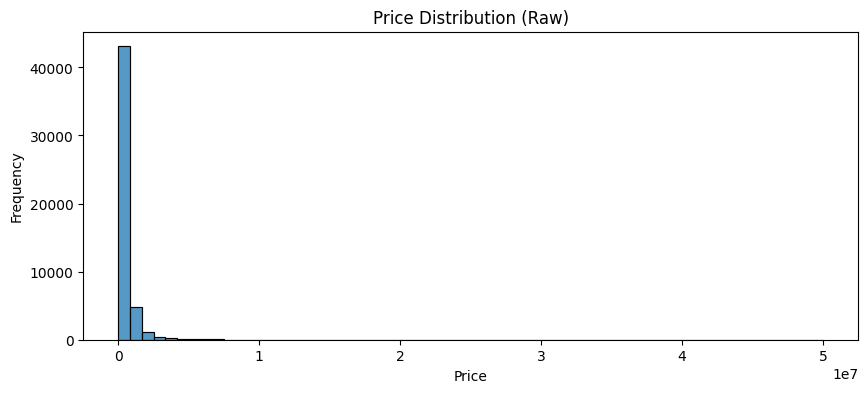

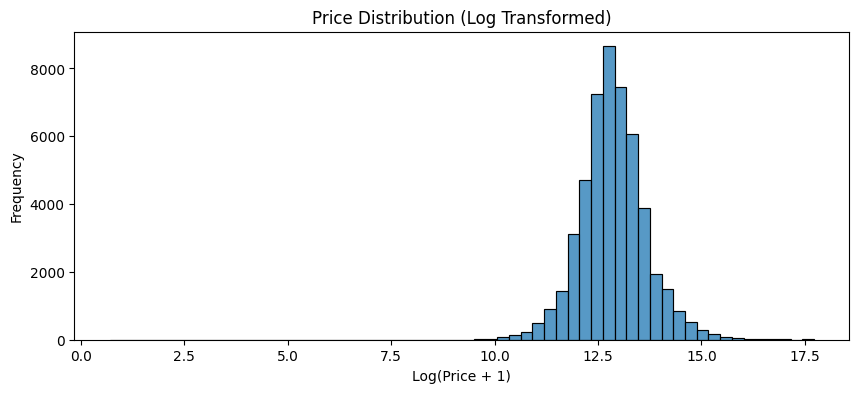

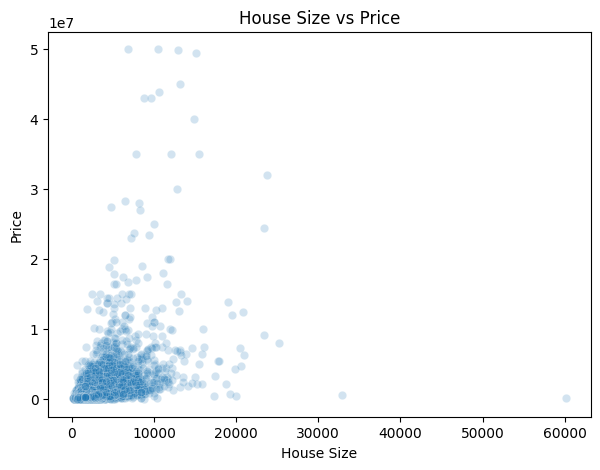

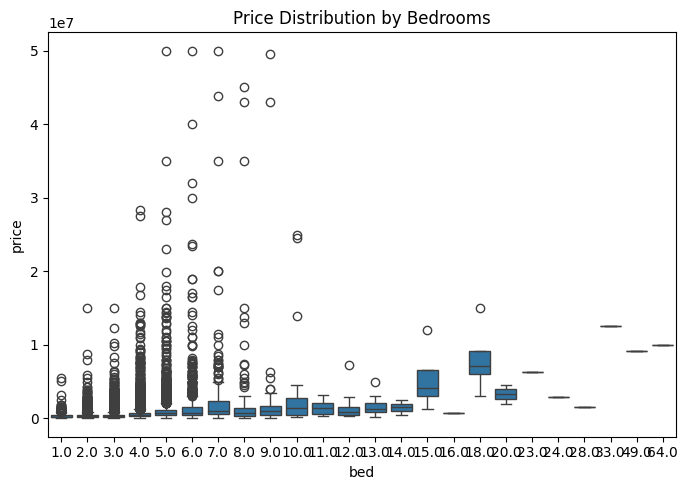

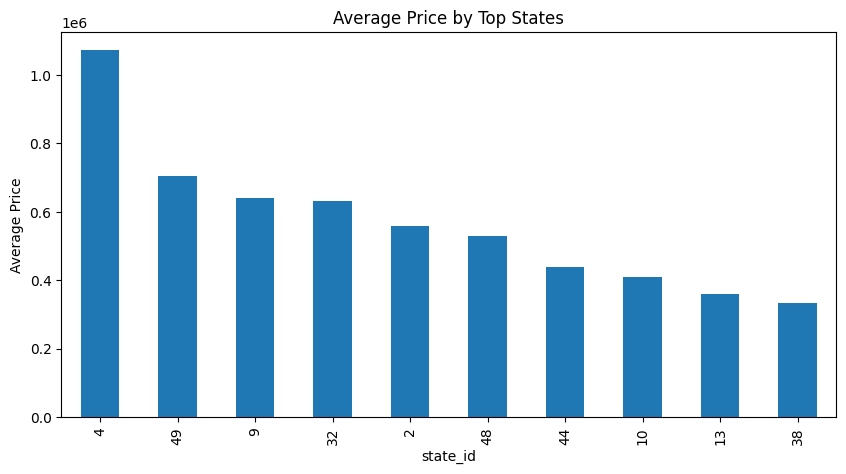

In [37]:
display(data.describe(include="all").T)

# Price Distribution - Original scale
plt.figure(figsize=(10, 4))
sns.histplot(data["price"], bins=60, kde=False)
plt.title("Price Distribution (Raw)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Price Distribution - Log scale
plt.figure(figsize=(10, 4))
sns.histplot(np.log1p(data["price"]), bins=60, kde=False)
plt.title("Price Distribution (Log Transformed)")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

# Sample for faster EDA plotting
eda_sample = data.sample(n=min(50_000, len(data)), random_state=42)

# House Size vs Price
plt.figure(figsize=(7, 5))
sns.scatterplot(data=eda_sample, x="house_size", y="price", alpha=0.2)
plt.title("House Size vs Price")
plt.xlabel("House Size")
plt.ylabel("Price")
plt.show()

# Price by Number of Bedrooms
plt.figure(figsize=(7, 5))
sns.boxplot(data=eda_sample, x="bed", y="price")
plt.title("Price Distribution by Bedrooms")
plt.tight_layout()
plt.show()

# Average Price by Top States
top_state_ids = data["state_id"].value_counts().head(10).index
state_avg_price = data[data["state_id"].isin(top_state_ids)] \
    .groupby("state_id")["price"].mean() \
    .sort_values(ascending=False)

plt.figure(figsize=(10, 5))
state_avg_price.plot(kind="bar")
plt.title("Average Price by Top States")
plt.ylabel("Average Price")
plt.show()

In [38]:
# Model Evaluation Function
def evaluate_model(y_true_log, y_pred_log):
    """
    Evaluates regression model trained on log1p(price).
    Returns metrics on both log scale and original price scale.
    """
    # Log scale performance
    r2_log = r2_score(y_true_log, y_pred_log)

    # Convert back to original price scale
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_original = r2_score(y_true, y_pred)

    return {
        "R2_log": round(r2_log, 4),
        "MAE_price": round(mae, 2),
        "RMSE_price": round(rmse, 2),
        "R2_price": round(r2_original, 4)
    }

In [39]:
target = "price"

# Features and target (log-transformed)
X = data.drop(columns=[target]).copy()
y = np.log1p(data[target].values)

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (35000, 9)
Test set shape: (15000, 9)


In [40]:
# Neural Network - MLPRegressor
mlp_settings = {
    "hidden_layer_sizes": (64, 32),
    "activation": "relu",
    "solver": "adam",
    "alpha": 1e-4,
    "learning_rate_init": 1e-3,
    "max_iter": 250,
    "early_stopping": True,
    "random_state": 42   # Using direct value to avoid dependency
}

# Cross-validation score
mlp_cv_r2 = cv_r2_score(X_train, y_train, MLPRegressor, mlp_settings,
                       preprocess_type="scaled", k="all")

# Train final model and get predictions
mlp_model, mlp_imp, mlp_sc, mlp_sel, mlp_pred = fit_full_model(
    X_train, y_train, X_test,
    MLPRegressor, mlp_settings,
    preprocess_type="scaled", k="all"
)

# Evaluate performance
mlp_metrics = evaluate_model(y_test, mlp_pred)

print("MLP REGRESSOR (NEURAL NETWORK)")
print("CV R2 (log scale):", round(mlp_cv_r2, 4))
print({k: round(v, 4) if "R2" in k else round(v, 2)
       for k, v in mlp_metrics.items()})

MLP REGRESSOR (NEURAL NETWORK)
CV R2 (log scale): 0.5789
{'R2_log': 0.6236, 'MAE_price': 228457.03, 'RMSE_price': np.float64(898604.08), 'R2_price': 0.3412}


In [41]:
# Preprocessing & Helper Functions

num_features = X_train.columns.tolist()

def calculate_mi_scores(X_arr, y_arr):
    """Mutual Information for feature selection"""
    return mutual_info_regression(X_arr, y_arr, random_state=42)

def fit_scaled_preprocessing(X_df):
    """Fit imputer + scaler on training data"""
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_imputed = imputer.fit_transform(X_df)
    X_scaled = scaler.fit_transform(X_imputed)

    return imputer, scaler, X_scaled

def apply_scaled_preprocessing(X_df, imputer, scaler):
    """Apply preprocessing on new data"""
    X_imputed = imputer.transform(X_df)
    return scaler.transform(X_imputed)

def fit_tree_preprocessing(X_df):
    """Fit only imputer (for tree-based models)"""
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X_df)
    return imputer, X_imputed

def apply_tree_preprocessing(X_df, imputer):
    """Apply imputer on new data"""
    return imputer.transform(X_df)

def cv_r2_score(X_df, y_arr, model_cls, model_params, preprocess_type="scaled", k="all"):
    """Cross-validation R² score"""
    scores = []

    for train_idx, val_idx in cv.split(X_df):
        X_tr = X_df.iloc[train_idx]
        X_val = X_df.iloc[val_idx]
        y_tr = y_arr[train_idx]
        y_val = y_arr[val_idx]

        # Preprocessing
        if preprocess_type == "scaled":
            imp, sc, X_tr_p = fit_scaled_preprocessing(X_tr)
            X_val_p = apply_scaled_preprocessing(X_val, imp, sc)
        else:
            imp, X_tr_p = fit_tree_preprocessing(X_tr)
            X_val_p = apply_tree_preprocessing(X_val, imp)

        # Feature selection
        if k != "all":
            selector = SelectKBest(score_func=calculate_mi_scores, k=int(k))
            X_tr_p = selector.fit_transform(X_tr_p, y_tr)
            X_val_p = selector.transform(X_val_p)

        # Train and evaluate
        model = model_cls(**model_params)
        model.fit(X_tr_p, y_tr)
        pred = model.predict(X_val_p)
        scores.append(r2_score(y_val, pred))

    return float(np.mean(scores))

def fit_full_model(X_train_df, y_train_arr, X_test_df, model_cls, model_params,
                  preprocess_type="scaled", k="all"):
    """Train final model on full training data and predict on test set"""

    # Preprocessing
    if preprocess_type == "scaled":
        imp, sc, X_tr_p = fit_scaled_preprocessing(X_train_df)
        X_te_p = apply_scaled_preprocessing(X_test_df, imp, sc)
    else:
        imp, X_tr_p = fit_tree_preprocessing(X_train_df)
        X_te_p = apply_tree_preprocessing(X_test_df, imp)

    # Feature selection
    selector = None
    if k != "all":
        selector = SelectKBest(score_func=calculate_mi_scores, k=int(k))
        X_tr_p = selector.fit_transform(X_tr_p, y_train_arr)
        X_te_p = selector.transform(X_te_p)

    # Train model
    model = model_cls(**model_params)
    model.fit(X_tr_p, y_train_arr)
    pred_test = model.predict(X_te_p)

    return model, imp, (sc if preprocess_type == "scaled" else None), selector, pred_test

In [42]:
# Baseline Models

# 1. Linear Regression (with scaling)
lr_params = {}
lr_cv_r2 = cv_r2_score(X_train, y_train, LinearRegression, lr_params,
                      preprocess_type="scaled", k="all")

lr_model, lr_imp, lr_sc, lr_sel, lr_pred = fit_full_model(
    X_train, y_train, X_test,
    LinearRegression, lr_params,
    preprocess_type="scaled", k="all"
)

lr_metrics = evaluate_model(y_test, lr_pred)

print("LINEAR REGRESSION (BASELINE)")
print("CV R2 (log):", round(lr_cv_r2, 4))
print({k: round(v, 4) if "R2" in k else round(v, 2)
       for k, v in lr_metrics.items()})


# 2. Random Forest (tree-based preprocessing)
rf_params = {
    "random_state": 42,
    "n_estimators": 300,
    "n_jobs": -1
}

rf_cv_r2 = cv_r2_score(X_train, y_train, RandomForestRegressor, rf_params,
                      preprocess_type="tree", k="all")

rf_model, rf_imp, rf_sc, rf_sel, rf_pred = fit_full_model(
    X_train, y_train, X_test,
    RandomForestRegressor, rf_params,
    preprocess_type="tree", k="all"
)

rf_metrics = evaluate_model(y_test, rf_pred)

print("\nRANDOM FOREST (BASELINE)")
print("CV R2 (log):", round(rf_cv_r2, 4))
print({k: round(v, 4) if "R2" in k else round(v, 2)
       for k, v in rf_metrics.items()})

LINEAR REGRESSION (BASELINE)
CV R2 (log): 0.4222
{'R2_log': 0.4628, 'MAE_price': 293709.37, 'RMSE_price': np.float64(2398139.2), 'R2_price': -3.6918}

RANDOM FOREST (BASELINE)
CV R2 (log): 0.732
{'R2_log': 0.7657, 'MAE_price': 176368.2, 'RMSE_price': np.float64(803551.06), 'R2_price': 0.4732}


In [44]:
# Hyperparameter Tuning + Feature Selection for Linear Regression

k_options = [5, 7, 9, "all"]
fit_intercept_options = [True, False]

# Check if 'positive' parameter is supported
base_params = LinearRegression().get_params()
positive_options = [True, False] if "positive" in base_params else [None]

search_results = []
best_cv_score = -np.inf
best_config = None

for k in k_options:
    for fit_int in fit_intercept_options:
        for pos in positive_options:
            model_params = {"fit_intercept": fit_int}
            if pos is not None:
                model_params["positive"] = pos

            # Cross-validation score
            score = cv_r2_score(
                X_train, y_train,
                LinearRegression, model_params,
                preprocess_type="scaled",
                k=k
            )

            search_results.append({
                "k": k,
                "fit_intercept": fit_int,
                "positive": pos,
                "cv_r2_log": score
            })

            # Track best configuration
            if score > best_cv_score:
                best_cv_score = score
                best_config = {"k": k, **model_params}

# Results overview
search_df = pd.DataFrame(search_results).sort_values("cv_r2_log", ascending=False)
display(search_df.head(10))

print("Best Linear Regression config:", best_config)
print("Best CV R2 (log):", round(best_cv_score, 4))

# Train best model on full training data
best_lr_params = {k: v for k, v in best_config.items() if k != "k"}

lin_best_model, lin_best_imp, lin_best_sc, lin_best_sel, lin_best_pred = fit_full_model(
    X_train, y_train, X_test,
    LinearRegression,
    best_lr_params,
    preprocess_type="scaled",
    k=best_config["k"]
)

lin_best_metrics = evaluate_model(y_test, lin_best_pred)

,k,fit_intercept,positive,cv_r2_log
13,all,True,False,0.422170
9,9,True,False,0.422170
5,7,True,False,0.421739
1,5,True,False,0.419239
0,5,True,True,0.391420
12,all,True,True,0.391420
8,9,True,True,0.391420
4,7,True,True,0.391420
7,7,False,False,-248.248627
15,all,False,False,-248.249205


Best Linear Regression config: {'k': 9, 'fit_intercept': True, 'positive': False}
Best CV R2 (log): 0.4222


In [45]:
# Hyperparameter Tuning + Feature Selection for Random Forest (Faster Version)

param_grid = {
    "n_estimators": [150, 250, 400],
    "max_depth": [None, 15, 25, 35],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7],
}

k_options = [7, "all"]
n_iter_search = 12

# Generate parameter combinations
random_gen = np.random.RandomState(42)
param_combinations = list(ParameterSampler(param_grid, n_iter=n_iter_search, random_state=random_gen))

search_results = []
best_score = -np.inf
best_config = None

print("Starting Random Forest tuning... (this may still take a few minutes)")

for params in param_combinations:
    for k in k_options:
        model_params = dict(params)
        model_params["random_state"] = 42
        model_params["n_jobs"] = -1

        score = cv_r2_score(
            X_train, y_train,
            RandomForestRegressor, model_params,
            preprocess_type="tree",
            k=k
        )

        search_results.append({"k": k, **params, "cv_r2_log": score})

        if score > best_score:
            best_score = score
            best_config = {"k": k, **model_params}

# Results
search_df = pd.DataFrame(search_results).sort_values("cv_r2_log", ascending=False)
display(search_df.head(10))

print("Best Random Forest config:", {k: v for k, v in best_config.items()
                                   if k not in ["random_state", "n_jobs"]})
print("Best CV R2 (log):", round(best_score, 4))

# Train final best model
final_rf_params = {k: v for k, v in best_config.items() if k != "k"}

rf_best_model, rf_best_imp, rf_best_sc, rf_best_sel, rf_best_pred = fit_full_model(
    X_train, y_train, X_test,
    RandomForestRegressor,
    final_rf_params,
    preprocess_type="tree",
    k=best_config["k"]
)

rf_best_metrics = evaluate_model(y_test, rf_best_pred)

Starting Random Forest tuning... (this may still take a few minutes)


,k,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,cv_r2_log
18,7,250,5,1,0.7,25.0,0.739752
0,7,150,5,2,0.7,35.0,0.739574
4,7,150,5,1,0.7,25.0,0.739560
22,7,150,5,1,0.7,NaN,0.739182
1,all,150,5,2,0.7,35.0,0.738894
16,7,250,10,2,0.7,35.0,0.738312
17,all,250,10,2,0.7,35.0,0.738296
19,all,250,5,1,0.7,25.0,0.737999
5,all,150,5,1,0.7,25.0,0.737381
23,all,150,5,1,0.7,NaN,0.737167


Best Random Forest config: {'k': 7, 'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 25}
Best CV R2 (log): 0.7398


In [47]:
# Get Selected Feature Names
def get_selected_features(selector, all_feature_names):
    """
    Returns the list of features selected by SelectKBest.
    If no selector was used, returns all features.
    """
    if selector is None:
        return all_feature_names

    selected_mask = selector.get_support()
    return [name for name, is_selected in zip(all_feature_names, selected_mask) if is_selected]

# Extract selected features
lin_selected_features = get_selected_features(lin_best_sel, num_features)
rf_selected_features = get_selected_features(rf_best_sel, num_features)

print("Linear Regression selected features:", lin_selected_features)
print("Random Forest selected features:", rf_selected_features)

Linear Regression selected features: ['status', 'bed', 'bath', 'acre_lot', 'zip_code', 'house_size', 'sold_year', 'state_id', 'city_id']
Random Forest selected features: ['bed', 'bath', 'acre_lot', 'zip_code', 'house_size', 'state_id', 'city_id']


In [50]:
comparison_data = [
    {
        "Model": "Linear Regression (Baseline)",
        "Features Used": f"All ({len(num_features)})",
        "CV R2 (log)": lr_cv_r2,
        "Test RMSE": lr_metrics["RMSE_price"],
        "Test R2 (log)": lr_metrics["R2_log"],
    },
    {
        "Model": "Random Forest (Baseline)",
        "Features Used": f"All ({len(num_features)})",
        "CV R2 (log)": rf_cv_r2,
        "Test RMSE": rf_metrics["RMSE_price"],
        "Test R2 (log)": rf_metrics["R2_log"],
    },
    {
        "Model": "MLP Regressor",
        "Features Used": f"All ({len(num_features)})",
        "CV R2 (log)": mlp_cv_r2,
        "Test RMSE": mlp_metrics["RMSE_price"],
        "Test R2 (log)": mlp_metrics["R2_log"],
    },
    {
        "Model": "Linear Regression (Tuned + FS)",
        "Features Used": f"Selected ({len(lin_selected_features)})",
        "CV R2 (log)": best_cv_score,
        "Test RMSE": lin_best_metrics["RMSE_price"],
        "Test R2 (log)": lin_best_metrics["R2_log"],
    },
    {
        "Model": "Random Forest (Tuned + FS)",
        "Features Used": f"Selected ({len(rf_selected_features)})",
        "CV R2 (log)": best_score,
        "Test RMSE": rf_best_metrics["RMSE_price"],
        "Test R2 (log)": rf_best_metrics["R2_log"],
    },
]

results_table = pd.DataFrame(comparison_data)
display(results_table)

,Model,Features Used,CV R2 (log),Test RMSE,Test R2 (log)
0,Linear Regression (Baseline),All (9),0.422170,2398139.20,0.4628
1,Random Forest (Baseline),All (9),0.732035,803551.06,0.7657
2,MLP Regressor,All (9),0.578927,898604.08,0.6236
3,Linear Regression (Tuned + FS),Selected (9),0.422170,2398139.20,0.4628
4,Random Forest (Tuned + FS),Selected (7),0.739752,805495.44,0.7689
